# evaluate_rf.ipynb
Loads the saved **Random Forest** model from `pipeline.py` and produces confusion matrices, threshold curves, calibration plots, and feature importance analysis.

> **Splits must match `pipeline.py` exactly** — same `test_size` and `random_state` values.

In [1]:
import sys
sys.path.append('/home/james/ml-proj/predmain/src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import matthews_corrcoef, f1_score, recall_score, precision_score

from features import engineer_features, get_feature_columns, get_target_column
from evaluate import plot_confusion_matrix

sns.set_theme(style='darkgrid')

MODEL_PATH = '/home/james/ml-proj/predmain/outputs/models/rf_model.pkl'

saved     = joblib.load(MODEL_PATH)
model     = saved['model']
THRESHOLD = float(saved['threshold'])

# Recreate the exact same 80/10/10 split as pipeline.py
df = pd.read_csv('/home/james/ml-proj/predmain/data/ai4i2020.csv')
df = df.drop(columns=['UDI', 'Product ID'], errors='ignore')
df = engineer_features(df)

X = df[get_feature_columns()]
y = df[get_target_column()]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f'Model:     Random Forest')
print(f'Features:  {get_feature_columns()}')
print(f'Threshold: {THRESHOLD}  (auto-selected on val, >=80% recall constraint)')
print(f'Split:     train {len(X_train)} / val {len(X_val)} / test {len(X_test)}')

Dropped 19 RNF rows (10000 → 9981)
Model:     Random Forest
Features:  ['air_temp_K', 'proc_temp_K', 'rot_speed_rpm', 'torque_Nm', 'tool_wear_min', 'power_kW', 'temp_delta_K', 'torque_wear', 'product_type']
Threshold: 0.48  (auto-selected on val, >=80% recall constraint)
Split:     train 7984 / val 998 / test 999


## 1 · Confusion matrices

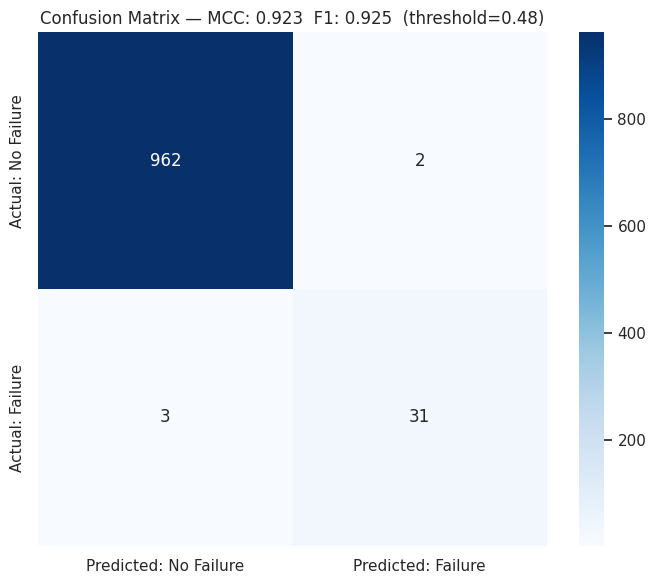

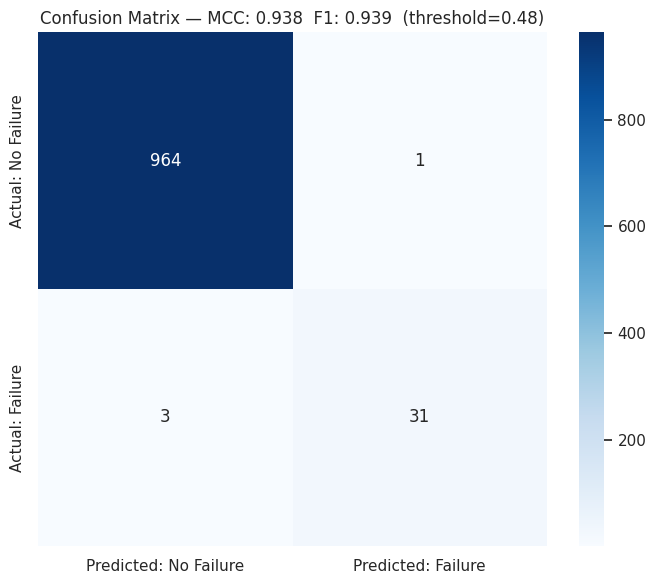

 Set   MCC    F1  Recall  Precision
 Val 0.923 0.925   0.912      0.939
Test 0.938 0.939   0.912      0.969
Mean 0.930 0.932   0.912      0.954

Val classification report:
              precision    recall  f1-score   support

  No Failure       1.00      1.00      1.00       964
     Failure       0.94      0.91      0.93        34

    accuracy                           0.99       998
   macro avg       0.97      0.95      0.96       998
weighted avg       0.99      0.99      0.99       998

Test classification report:
              precision    recall  f1-score   support

  No Failure       1.00      1.00      1.00       965
     Failure       0.97      0.91      0.94        34

    accuracy                           1.00       999
   macro avg       0.98      0.96      0.97       999
weighted avg       1.00      1.00      1.00       999



In [2]:
val_m  = plot_confusion_matrix(model, X_val,  y_val,  threshold=THRESHOLD,
    save_path='/home/james/ml-proj/predmain/outputs/figures/confusion_matrix_rf_val.png')
test_m = plot_confusion_matrix(model, X_test, y_test, threshold=THRESHOLD,
    save_path='/home/james/ml-proj/predmain/outputs/figures/confusion_matrix_rf_test.png')

results = pd.DataFrame([
    {'Set': 'Val',  'MCC': round(val_m['mcc'],  3), 'F1': round(val_m['f1'],  3),
     'Recall': round(val_m['recall'],  3), 'Precision': round(val_m['precision'],  3)},
    {'Set': 'Test', 'MCC': round(test_m['mcc'], 3), 'F1': round(test_m['f1'], 3),
     'Recall': round(test_m['recall'], 3), 'Precision': round(test_m['precision'], 3)},
    {'Set': 'Mean',
     'MCC':       round((val_m['mcc']       + test_m['mcc'])       / 2, 3),
     'F1':        round((val_m['f1']        + test_m['f1'])        / 2, 3),
     'Recall':    round((val_m['recall']    + test_m['recall'])    / 2, 3),
     'Precision': round((val_m['precision'] + test_m['precision']) / 2, 3)},
])
print(results.to_string(index=False))
print()
print('Val classification report:')
print(val_m['report'])
print('Test classification report:')
print(test_m['report'])

## 2 · Threshold sweep

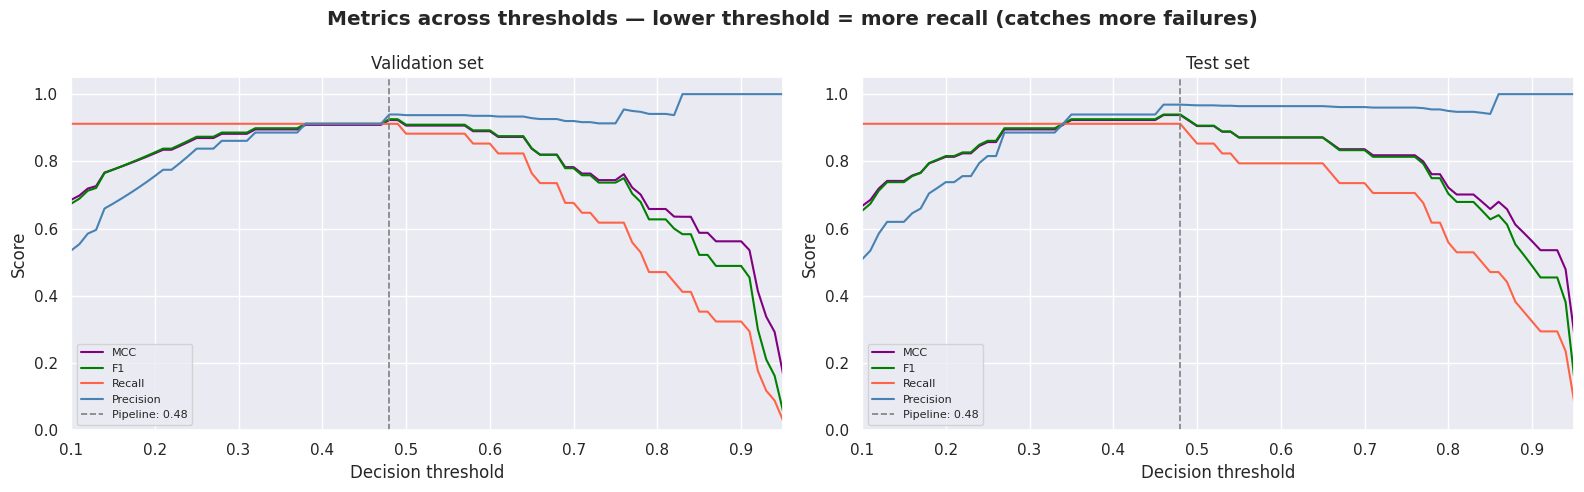

In [3]:
sweep_t = np.arange(0.10, 0.96, 0.01)

def metrics_at_thresholds(y_true, y_proba, thresholds):
    rows = []
    for t in thresholds:
        yp = (y_proba >= t).astype(int)
        rows.append({
            'threshold': round(float(t), 2),
            'mcc':       float(matthews_corrcoef(y_true, yp)),
            'f1':        float(f1_score(y_true, yp, zero_division=0)),
            'recall':    float(recall_score(y_true, yp, zero_division=0)),
            'precision': float(precision_score(y_true, yp, zero_division=0)),
        })
    return pd.DataFrame(rows)

val_proba  = model.predict_proba(X_val)[:, 1]
test_proba = model.predict_proba(X_test)[:, 1]

val_df  = metrics_at_thresholds(y_val,  val_proba,  sweep_t)
test_df = metrics_at_thresholds(y_test, test_proba, sweep_t)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, df_plot, title in [(axes[0], val_df, 'Validation'), (axes[1], test_df, 'Test')]:
    ax.plot(df_plot.threshold, df_plot.mcc,       color='purple',    lw=1.5, label='MCC')
    ax.plot(df_plot.threshold, df_plot.f1,        color='green',     lw=1.5, label='F1')
    ax.plot(df_plot.threshold, df_plot.recall,    color='tomato',    lw=1.5, label='Recall')
    ax.plot(df_plot.threshold, df_plot.precision, color='steelblue', lw=1.5, label='Precision')
    ax.axvline(THRESHOLD, color='gray', ls='--', lw=1.2, label=f'Pipeline: {THRESHOLD}')
    ax.set_xlabel('Decision threshold')
    ax.set_ylabel('Score')
    ax.set_title(f'{title} set')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_xlim(0.10, 0.95)

plt.suptitle('Metrics across thresholds — lower threshold = more recall (catches more failures)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('/home/james/ml-proj/predmain/outputs/figures/threshold_curve_rf.png', dpi=150)
plt.show()


## 3 · Calibration check

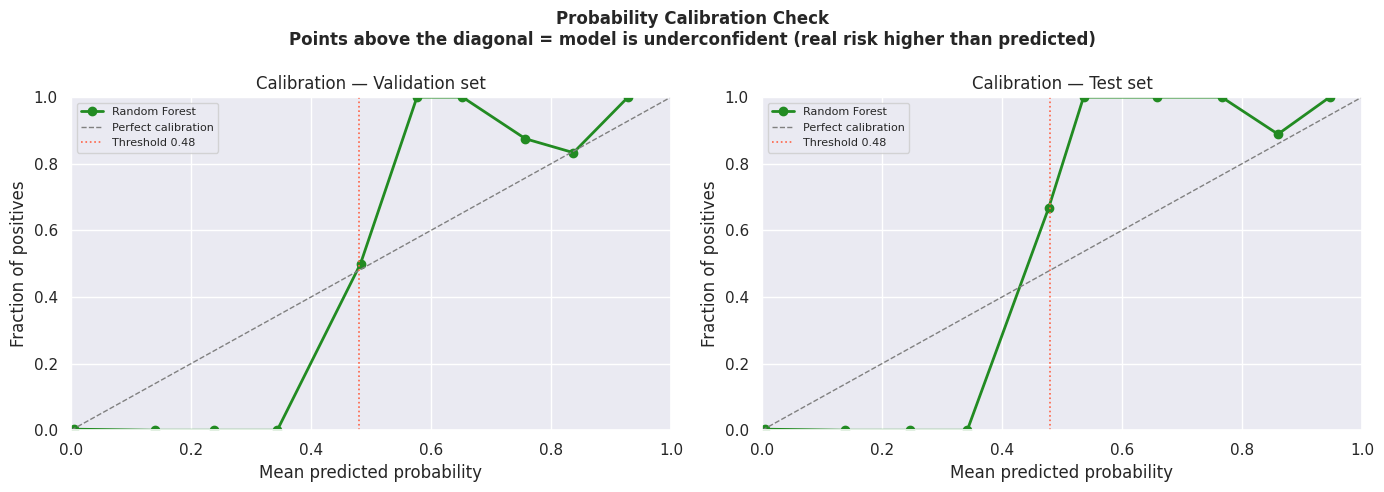

In [4]:
from sklearn.calibration import calibration_curve

test_proba_cal = model.predict_proba(X_test)[:, 1]
val_proba_cal  = model.predict_proba(X_val)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, proba, y_true, title in [
    (axes[0], val_proba_cal,  y_val,  'Validation'),
    (axes[1], test_proba_cal, y_test, 'Test'),
]:
    prob_true, prob_pred = calibration_curve(y_true, proba, n_bins=10, strategy='uniform')
    ax.plot(prob_pred, prob_true, 'o-', color='forestgreen', lw=2, label='Random Forest')
    ax.plot([0, 1], [0, 1], '--', color='gray', lw=1, label='Perfect calibration')
    ax.axvline(THRESHOLD, color='tomato', ls=':', lw=1.2, label=f'Threshold {THRESHOLD}')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_title(f'Calibration — {title} set')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.suptitle('Probability Calibration Check\n'
             'Points above the diagonal = model is underconfident (real risk higher than predicted)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('/home/james/ml-proj/predmain/outputs/figures/calibration_rf.png', dpi=150)
plt.show()


## 4 · Feature importance (permutation-based)

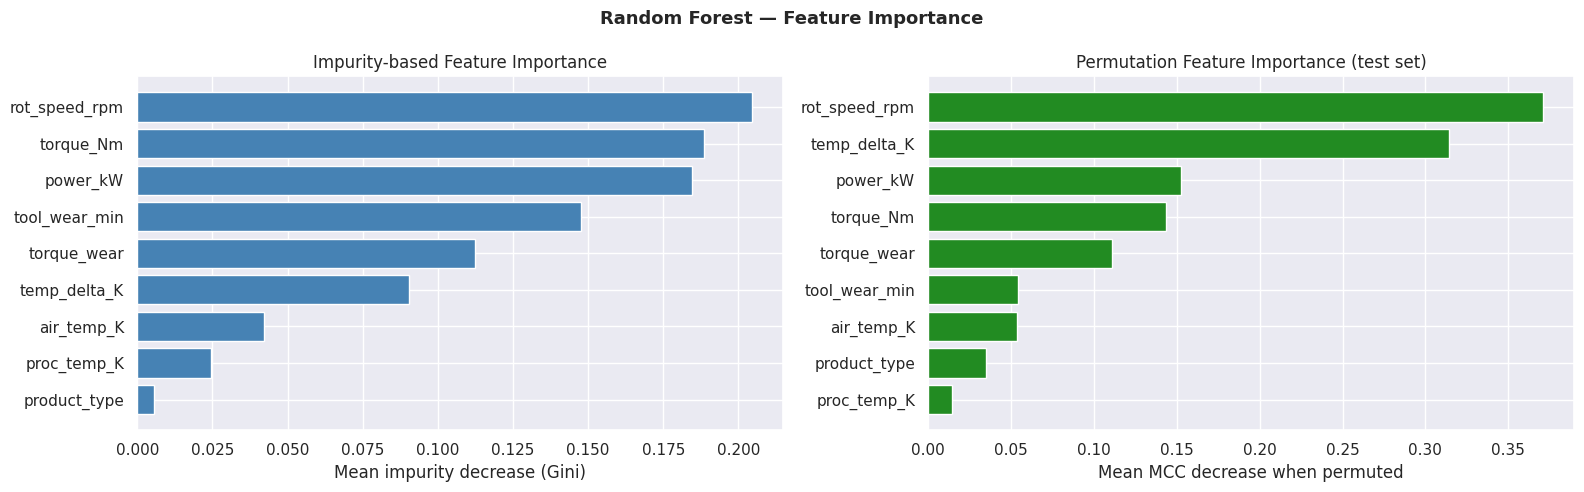

Feature importance summary (test set):
         Feature  Gini Importance  Permutation Importance
1  rot_speed_rpm           0.2046                  0.3711
2   temp_delta_K           0.0903                  0.3144
3       power_kW           0.1844                  0.1528
4      torque_Nm           0.1887                  0.1433
5    torque_wear           0.1123                  0.1107
6  tool_wear_min           0.1476                  0.0540
7     air_temp_K           0.0422                  0.0535
8   product_type           0.0055                  0.0346
9    proc_temp_K           0.0244                  0.0144


In [5]:
# Random Forest feature importance via sklearn's built-in impurity-based
# importance AND permutation importance (more reliable for correlated features).
from sklearn.inspection import permutation_importance

feature_names = get_feature_columns()

# Impurity-based (Gini) importance — built into RF
gini_imp = pd.Series(model.feature_importances_, index=feature_names).sort_values()

# Permutation importance on test set — measures actual impact on MCC
perm_result = permutation_importance(
    model, X_test, y_test,
    n_repeats=20,
    random_state=42,
    scoring='matthews_corrcoef',
    n_jobs=-1,
)
perm_imp = pd.Series(
    perm_result.importances_mean,  # type: ignore[union-attr]
    index=feature_names,
).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gini importance
axes[0].barh(gini_imp.index, gini_imp.values, color='steelblue')
axes[0].set_xlabel('Mean impurity decrease (Gini)')
axes[0].set_title('Impurity-based Feature Importance')

# Permutation importance
axes[1].barh(perm_imp.index, perm_imp.values, color='forestgreen')
axes[1].set_xlabel('Mean MCC decrease when permuted')
axes[1].set_title('Permutation Feature Importance (test set)')

plt.suptitle('Random Forest — Feature Importance', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('/home/james/ml-proj/predmain/outputs/figures/rf_feature_importance.png', dpi=150)
plt.show()

# Summary table
imp_table = pd.DataFrame({
    'Feature': feature_names,
    'Gini Importance': [round(gini_imp[f], 4) for f in feature_names],
    'Permutation Importance': [round(perm_imp[f], 4) for f in feature_names],
}).sort_values('Permutation Importance', ascending=False).reset_index(drop=True)
imp_table.index += 1
print("Feature importance summary (test set):")
print(imp_table.to_string())

## 5 · Failure miss diagnostic

Val + test only (1997 rows):
  Total failures:  68
  Caught (TP):     62
  Missed (FN):     6  (8.8% miss rate)
  Misses by split: {'val': 3, 'test': 3}

Model confidence:
  Caught — mean: 0.806  min: 0.485
  Missed — mean: 0.045  max: 0.099

Mean feature values (val + test):
                 air_temp_K  proc_temp_K  rot_speed_rpm  torque_Nm  tool_wear_min  power_kW  temp_delta_K  torque_wear  product_type
Healthy             299.975      309.994       1537.979     39.813        107.480     6.270        10.018     4284.977         0.501
Caught failures     300.865      310.031       1439.645     53.326        149.419     7.635         9.166     7916.081         0.210
Missed failures     300.283      310.417       1674.000     31.917        174.500     5.395        10.133     5040.583         0.833

Mean |z-score| vs caught failure profile:
torque_Nm        1.565
product_type     1.546
power_kW         1.367
temp_delta_K     1.197
tool_wear_min    1.057
proc_temp_K      0.889
rot_speed_

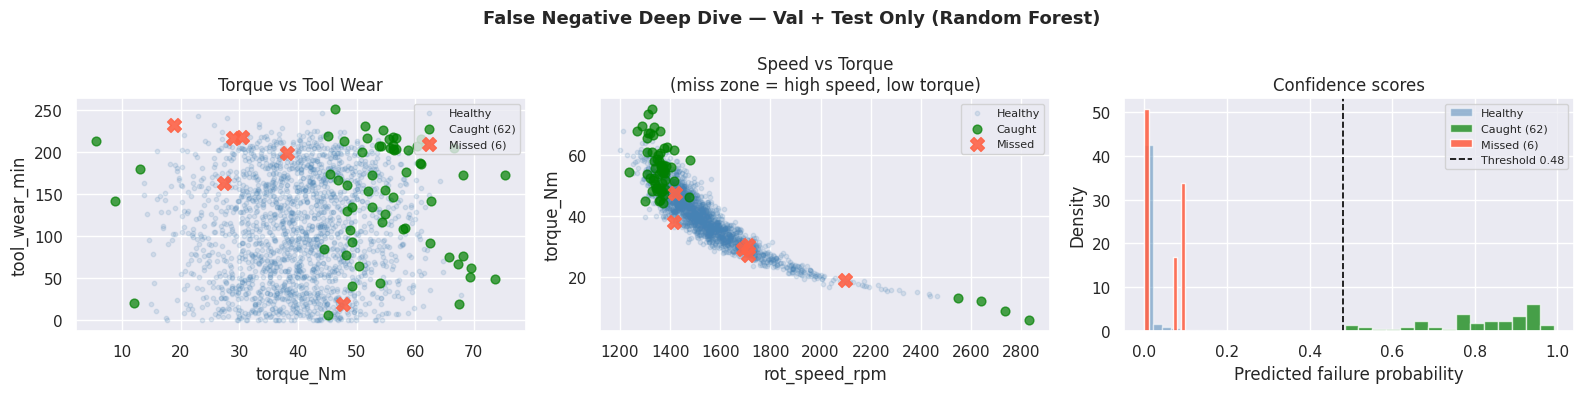


All missed failures:
      air_temp_K  proc_temp_K  rot_speed_rpm  torque_Nm  tool_wear_min  power_kW  temp_delta_K  torque_wear  product_type  proba split
599        300.7        311.7           2097       18.9            232     4.150          11.0       4384.8             1  0.099   val
1550       298.4        309.6           1710       27.3            163     4.888          11.2       4449.9             0  0.000  test
667        300.0        311.4           1692       29.0            216     5.138          11.4       6264.0             1  0.096   val
1459       302.3        310.9           1710       30.4            218     5.443           8.6       6627.2             1  0.071  test
892        298.4        308.0           1416       38.2            198     5.664           9.6       7563.6             1  0.003   val
1365       301.9        310.9           1419       47.7             20     7.088           9.0        954.0             1  0.000  test


In [6]:
# ── Val + test failure miss diagnostic ───────────────────────────────────────

eval_X = pd.concat([X_val, X_test], ignore_index=True)
eval_y = pd.concat([y_val, y_test], ignore_index=True)
eval_splits = ['val'] * len(X_val) + ['test'] * len(X_test)

eval_proba = model.predict_proba(eval_X)[:, 1]
eval_pred  = (eval_proba >= THRESHOLD).astype(int)

actual_fail = eval_y.values == 1
caught      = actual_fail & (eval_pred == 1)
missed      = actual_fail & (eval_pred == 0)
healthy     = eval_y.values == 0

print(f"Val + test only ({len(eval_X)} rows):")
print(f"  Total failures:  {actual_fail.sum()}")
print(f"  Caught (TP):     {caught.sum()}")
print(f"  Missed (FN):     {missed.sum()}  ({missed.sum()/actual_fail.sum():.1%} miss rate)")
print(f"  Misses by split: {pd.Series(eval_splits)[missed].value_counts().to_dict()}")
print()

if caught.sum() > 0 and missed.sum() > 0:
    print("Model confidence:")
    print(f"  Caught — mean: {eval_proba[caught].mean():.3f}  min: {eval_proba[caught].min():.3f}")
    print(f"  Missed — mean: {eval_proba[missed].mean():.3f}  max: {eval_proba[missed].max():.3f}")
    print()

    # Feature comparison
    compare = pd.DataFrame({
        'Healthy':         eval_X[healthy].mean(),
        'Caught failures': eval_X[caught].mean(),
        'Missed failures': eval_X[missed].mean(),
    }).T.round(3)
    print("Mean feature values (val + test):")
    print(compare.to_string())
    print()

    # Z-scores
    caught_means = eval_X[caught].mean()
    caught_stds  = eval_X[caught].std().replace(0, 1)
    z_scores = ((eval_X[missed] - caught_means) / caught_stds).abs().mean()
    print("Mean |z-score| vs caught failure profile:")
    print(z_scores.sort_values(ascending=False).round(3).to_string())
    print()

    # Plots
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].scatter(eval_X[healthy]['torque_Nm'],    eval_X[healthy]['tool_wear_min'],
                    alpha=0.15, s=10, color='steelblue', label='Healthy')
    axes[0].scatter(eval_X[caught]['torque_Nm'],     eval_X[caught]['tool_wear_min'],
                    alpha=0.7,  s=40, color='green',     label=f'Caught ({caught.sum()})', zorder=3)
    axes[0].scatter(eval_X[missed]['torque_Nm'],     eval_X[missed]['tool_wear_min'],
                    alpha=0.9,  s=100, color='tomato',   label=f'Missed ({missed.sum()})',
                    marker='X', zorder=4)
    axes[0].set_xlabel('torque_Nm')
    axes[0].set_ylabel('tool_wear_min')
    axes[0].set_title('Torque vs Tool Wear')
    axes[0].legend(fontsize=8)

    axes[1].scatter(eval_X[healthy]['rot_speed_rpm'], eval_X[healthy]['torque_Nm'],
                    alpha=0.15, s=10, color='steelblue', label='Healthy')
    axes[1].scatter(eval_X[caught]['rot_speed_rpm'],  eval_X[caught]['torque_Nm'],
                    alpha=0.7,  s=40, color='green',     label='Caught', zorder=3)
    axes[1].scatter(eval_X[missed]['rot_speed_rpm'],  eval_X[missed]['torque_Nm'],
                    alpha=0.9,  s=100, color='tomato',   label='Missed',
                    marker='X', zorder=4)
    axes[1].set_xlabel('rot_speed_rpm')
    axes[1].set_ylabel('torque_Nm')
    axes[1].set_title('Speed vs Torque\n(miss zone = high speed, low torque)')
    axes[1].legend(fontsize=8)

    axes[2].hist(eval_proba[healthy], bins=40, alpha=0.5, color='steelblue',
                 density=True, label='Healthy')
    axes[2].hist(eval_proba[caught], bins=15, alpha=0.7, color='green',
                 density=True, label=f'Caught ({caught.sum()})')
    axes[2].hist(eval_proba[missed], bins=10, alpha=0.9, color='tomato',
                 density=True, label=f'Missed ({missed.sum()})')
    axes[2].axvline(THRESHOLD, color='black', ls='--', lw=1.2, label=f'Threshold {THRESHOLD}')
    axes[2].set_xlabel('Predicted failure probability')
    axes[2].set_ylabel('Density')
    axes[2].set_title('Confidence scores')
    axes[2].legend(fontsize=8)

    plt.suptitle('False Negative Deep Dive — Val + Test Only (Random Forest)',
                 fontweight='bold', fontsize=13)
    plt.tight_layout()
    plt.savefig('/home/james/ml-proj/predmain/outputs/figures/miss_diagnostic_rf.png', dpi=150)
    plt.show()

    # Missed cases table
    missed_df = eval_X[missed].copy()
    missed_df['proba'] = eval_proba[missed]
    missed_df['split'] = pd.Series(eval_splits)[missed].values
    print("\nAll missed failures:")
    print(missed_df.sort_values('torque_Nm').round(3).to_string())
elif missed.sum() == 0:
    print("No missed failures! All failures caught.")
else:
    print("No caught failures at this threshold.")